<a href="https://colab.research.google.com/github/adamjtnrqlby53/Preprocessing-Data/blob/main/Preprocessing%20Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import hashlib
from PIL import Image
import matplotlib.pyplot as plt

In [ ]:
dataset_path = "/content/drive/MyDrive/UAS_VK&KK/Dataset"

In [ ]:
classes = sorted(os.listdir(dataset_path))

print("="*40)
print("DATASET AWAL")
print("="*40)

total = 0

for cls in classes:
    folder = os.path.join(dataset_path, cls)
    jumlah = len(os.listdir(folder))
    total += jumlah

    print(f"{cls} : {jumlah} gambar")

print("-"*40)
print("Total Dataset :", total)

DATASET AWAL
Objek_Botol : 100 gambar
Objek_Obeng : 100 gambar
Objek_Tanaman : 102 gambar
----------------------------------------
Total Dataset : 302


In [ ]:
rusak = 0

for cls in classes:

    folder = os.path.join(dataset_path, cls)

    for file in os.listdir(folder):

        path = os.path.join(folder,file)

        try:
            img = Image.open(path)
            img.verify()

        except:
            rusak += 1
            os.remove(path)

print("="*40)
print("HASIL CLEANING")
print("="*40)
print("File rusak yang dihapus :", rusak)

HASIL CLEANING
File rusak yang dihapus : 0


In [ ]:
hashes = {}
duplikat = 0

for cls in classes:

    folder = os.path.join(dataset_path, cls)

    for file in os.listdir(folder):

        path = os.path.join(folder,file)

        with open(path,"rb") as f:
            filehash = hashlib.md5(f.read()).hexdigest()

        if filehash in hashes:
            duplikat += 1
        else:
            hashes[filehash] = path

print("="*40)
print("HASIL DUPLIKAT")
print("="*40)
print("Jumlah gambar duplikat :", duplikat)

HASIL DUPLIKAT
Jumlah gambar duplikat : 0


In [ ]:
ukuran = (224,224)

for cls in classes:

    folder = os.path.join(dataset_path, cls)

    for file in os.listdir(folder):

        path = os.path.join(folder,file)

        img = Image.open(path)
        img = img.convert("RGB")
        img = img.resize(ukuran)
        img.save(path)

print("="*40)
print("RESIZE SELESAI")
print("="*40)
print("Ukuran gambar :", ukuran)

RESIZE SELESAI
Ukuran gambar : (224, 224)


In [ ]:
!pip install split-folders

In [ ]:
import splitfolders

splitfolders.ratio(
    dataset_path,
    output="/content/Dataset_Hasil",
    seed=42,
    ratio=(0.7,0.15,0.15)
)

print("Dataset berhasil dibagi.")

Copying files: 302 files [00:01, 157.21 files/s]

Dataset berhasil dibagi.


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    width_shift_range=0.2,
    height_shift_range=0.2
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

In [ ]:
train_generator = train_datagen.flow_from_directory(
    "/content/Dataset_Hasil/train",
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical"
)

validation_generator = test_datagen.flow_from_directory(
    "/content/Dataset_Hasil/val",
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical"
)

test_generator = test_datagen.flow_from_directory(
    "/content/Dataset_Hasil/test",
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)

Found 211 images belonging to 3 classes.
Found 45 images belonging to 3 classes.
Found 46 images belonging to 3 classes.


In [ ]:
print("="*40)
print("LABEL ENCODING")
print("="*40)
print(train_generator.class_indices)

LABEL ENCODING
{'Objek_Botol': 0, 'Objek_Obeng': 1, 'Objek_Tanaman': 2}


In [ ]:
print("="*40)
print("HASIL PEMBAGIAN DATASET")
print("="*40)

print("Training   :", train_generator.samples)
print("Validation :", validation_generator.samples)
print("Testing    :", test_generator.samples)

HASIL PEMBAGIAN DATASET
Training   : 211
Validation : 45
Testing    : 46


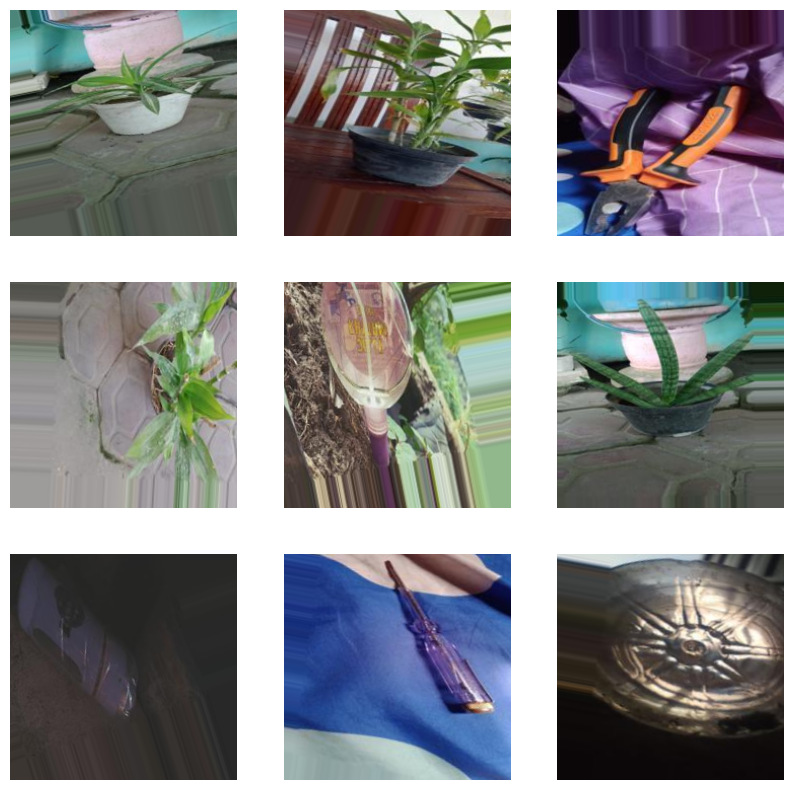

In [ ]:
images, labels = next(train_generator)

plt.figure(figsize=(10,10))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i])
    plt.axis("off")

plt.show()